In [52]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [2]:
df = pd.read_excel("../data/raw/all_article_data.xlsx")

In [3]:
df.head()

,row_id,paper_id,year,inhibitor,substrate,acid_type,acid_molarity_M,temperature_K,immersion_time_min,qe_concentration_ppm,method,IE_percent,is_blank,row_flag,source_table,notes
0,1,P1,2023,QE,St37,HCl,1,298,30,0,polarization,0.0,Yes,ok,P1_Table2,blank standardized to 0 ppm
1,2,P1,2023,QE,St37,HCl,1,298,30,200,polarization,67.8,No,ok,P1_Table2,NaN
2,3,P1,2023,QE,St37,HCl,1,298,30,400,polarization,69.0,No,ok,P1_Table2,NaN
3,4,P1,2023,QE,St37,HCl,1,298,30,600,polarization,79.5,No,ok,P1_Table2,NaN
4,5,P1,2023,QE,St37,HCl,1,298,30,800,polarization,90.4,No,ok,P1_Table2,NaN


In [4]:
df1= pd.read_excel("../data/processed/clean_article_data.xlsx")

In [47]:
df1.head()

,row_id,paper_id,year,inhibitor,substrate,acid_type,acid_molarity_M,temperature_K,immersion_time_min,qe_concentration_ppm,method,IE_percent,is_blank,row_flag,source_table,notes,method_code,acid_code
0,1,P1,2023,QE,St37,HCl,1,298,30,0,polarization,0.0,Yes,ok,P1_Table2,blank standardized to 0 ppm,0,0
1,2,P1,2023,QE,St37,HCl,1,298,30,200,polarization,67.8,No,ok,P1_Table2,NaN,0,0
2,3,P1,2023,QE,St37,HCl,1,298,30,400,polarization,69.0,No,ok,P1_Table2,NaN,0,0
3,4,P1,2023,QE,St37,HCl,1,298,30,600,polarization,79.5,No,ok,P1_Table2,NaN,0,0
4,5,P1,2023,QE,St37,HCl,1,298,30,800,polarization,90.4,No,ok,P1_Table2,NaN,0,0


In [6]:
df1["method_code"] = df1["method"].map({"polarization": 0,"EIS": 1})
df1["acid_code"]=df1["acid_type"].map({"HCl":0,"H2SO4":1})

##### Check categorical feature encoding

In [7]:
df1[["method", "method_code"]].drop_duplicates()

,method,method_code
0,polarization,0
7,EIS,1


In [8]:
df1[["acid_type", "acid_code"]].drop_duplicates()

,acid_type,acid_code
0,HCl,0
41,H2SO4,1


## Version 2 - Correlation Analysis

In [48]:
correlation_data=df1[['temperature_K','qe_concentration_ppm','method_code','acid_code','IE_percent']]
correlation_matrix=correlation_data.corr()

In [49]:
correlation_matrix

,temperature_K,qe_concentration_ppm,method_code,acid_code,IE_percent
temperature_K,1.000000,-0.043145,0.032382,-0.492402,-0.189606
qe_concentration_ppm,-0.043145,1.000000,-0.008657,0.027820,0.862398
method_code,0.032382,-0.008657,1.000000,-0.010626,-0.024569
acid_code,-0.492402,0.027820,-0.010626,1.000000,0.055093
IE_percent,-0.189606,0.862398,-0.024569,0.055093,1.000000


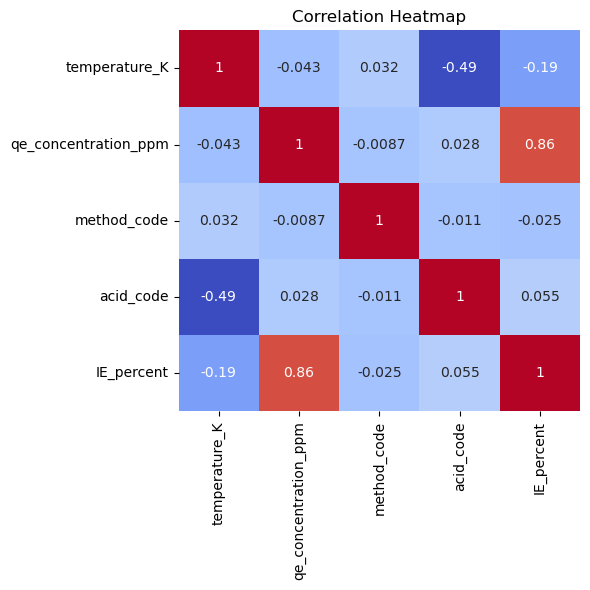

In [56]:
plt.figure(figsize=(6,6))
sns.heatmap(correlation_matrix,cmap="coolwarm",annot=True,cbar=False)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("../reports/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
X= df1[['temperature_K','qe_concentration_ppm','method_code','acid_code']]

In [10]:
y= df1['IE_percent']

In [11]:
X.head()

,temperature_K,qe_concentration_ppm,method_code,acid_code
0,298,0,0,0
1,298,200,0,0
2,298,400,0,0
3,298,600,0,0
4,298,800,0,0


In [12]:
y.head()

0     0.0
1    67.8
2    69.0
3    79.5
4    90.4
Name: IE_percent, dtype: float64

In [13]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=101)

In [14]:
lm=LinearRegression()

In [15]:
lm.fit(X_train,y_train)

LinearRegression()

In [16]:
pred_lm=lm.predict(X_test)

In [17]:
pred_lm

array([93.60479826, 37.35288912, 47.71657392, 32.79000188, 92.42167957,
       86.69604021, 63.75165417, 18.97193805, 92.49629005, 52.27946116,
       90.15041923])

In [18]:
y_test

18    91.0
1     67.8
43    73.3
42    51.5
35    77.9
26    81.0
16    81.0
14     0.0
46    86.3
2     69.0
22    85.0
Name: IE_percent, dtype: float64

In [19]:
mae=mean_absolute_error(y_test,pred_lm)
print('MAE:',mae)

MAE: 14.7136895560904


In [20]:
rmse=np.sqrt(mean_squared_error(y_test,pred_lm))
print('RMSE:',rmse)

RMSE: 17.012424393432525


In [21]:
r2=r2_score(y_test,pred_lm)
print('R2:',r2)

R2: 0.5095730552332751


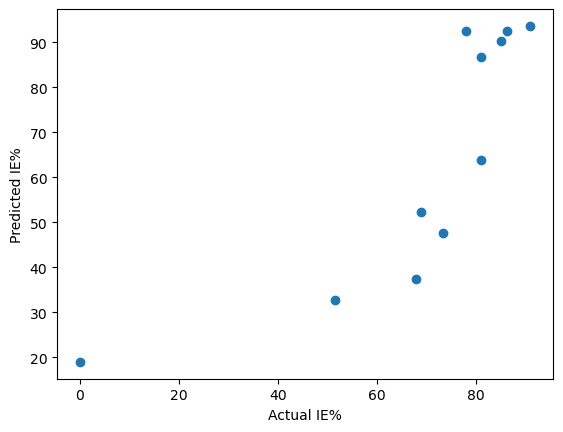

In [22]:
plt.scatter(y_test, pred_lm)
plt.xlabel('Actual IE%')
plt.ylabel('Predicted IE%')
plt.show()

In [23]:
lm.score(X_test,y_test)

0.5095730552332751

### RandomForest

In [24]:
from sklearn.ensemble import RandomForestRegressor

In [25]:
rfr=RandomForestRegressor(n_estimators=100,random_state=101)

In [26]:
rfr.fit(X_train,y_train)

RandomForestRegressor(random_state=101)

In [27]:
pred_rf=rfr.predict(X_test)

In [28]:
rfr.score(X_test,y_test)

0.9761610782013751

In [29]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [30]:
print('MAE:',mean_absolute_error(y_test,pred_rf))

MAE: 2.943999999999994


In [31]:
print('MSE:',mean_squared_error(y_test,pred_rf))

MSE: 14.0683998181818


In [32]:
print('RMSE:',np.sqrt(mean_squared_error(y_test,pred_rf)))

RMSE: 3.750786559934036


### XGBoost

In [33]:
from xgboost import XGBRegressor

In [34]:
xgb=XGBRegressor(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=101)

In [35]:
xgb.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=101, ...)

In [36]:
pred_xgb=xgb.predict(X_test)

In [37]:
xgb.score(X_test,y_test)

0.9824811975563001

In [38]:
print('Model Score R2:', xgb.score(X_test, y_test))
print('MAE:', mean_absolute_error(y_test, pred_xgb))
print('MSE:', mean_squared_error(y_test, pred_xgb))
print('RMSE:', np.sqrt(mean_squared_error(y_test, pred_xgb)))
print('R2:', r2_score(y_test, pred_xgb))

Model Score R2: 0.9824811975563001
MAE: 2.202046785571359
MSE: 10.338618465870637
RMSE: 3.215372212648271
R2: 0.9824811975563001


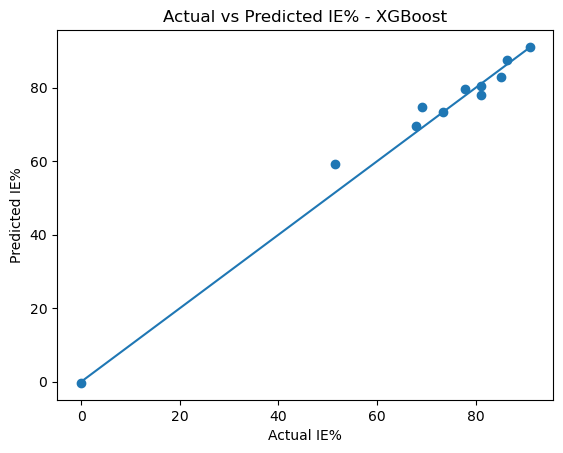

In [39]:
plt.scatter(y_test, pred_xgb)
min_value = min(y_test.min(), pred_xgb.min())
max_value = max(y_test.max(), pred_xgb.max())
plt.plot([min_value, max_value], [min_value, max_value])
plt.xlabel("Actual IE%")
plt.ylabel("Predicted IE%")
plt.title("Actual vs Predicted IE% - XGBoost")
plt.savefig("../reports/xgboost_actual_vs_predicted.png",dpi=300,bbox_inches="tight")
plt.show()

In [40]:
def get_metrics(model_name,y_test,predictions):
    return {'model':model_name,
            'MAE':mean_absolute_error(y_test,predictions),
            'MSE':mean_squared_error(y_test,predictions),
            'RMSE':np.sqrt(mean_squared_error(y_test,predictions)),
            'R2':r2_score(y_test,predictions)}

In [41]:
results=[]
results.append(get_metrics('Linear Regression',y_test,pred_lm))
results.append(get_metrics('Random Forest',y_test,pred_rf))
results.append(get_metrics('XGBoost',y_test,pred_xgb))

In [42]:
results_df=pd.DataFrame(results)
results_df=results_df.round(3)
results_df.to_csv('../reports/model_comparison_results.csv',index=False)

In [43]:
results_df

,model,MAE,MSE,RMSE,R2
0,Linear Regression,14.714,289.423,17.012,0.510
1,Random Forest,2.944,14.068,3.751,0.976
2,XGBoost,2.202,10.339,3.215,0.982


In [44]:
models={"Linear Regression":LinearRegression(),
        "Random Forest":RandomForestRegressor(n_estimators=100,random_state=101),
        "XGBoost":XGBRegressor(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=101)
        }
cv_results = []

for model_name, model in models.items():
    r2_scores = cross_val_score(model,X,y,cv=5,scoring="r2")
    mae_scores = cross_val_score(model,X,y,cv=5,scoring="neg_mean_absolute_error")
    rmse_scores = cross_val_score(model,X,y,cv=5,scoring="neg_root_mean_squared_error")

    cv_results.append({"model": model_name,"mean_R2": r2_scores.mean(),"std_R2": r2_scores.std(),"mean_MAE": -mae_scores.mean(),
                       "std_MAE": mae_scores.std(),"mean_RMSE": -rmse_scores.mean(),"std_RMSE": rmse_scores.std()})

cv_results_df = pd.DataFrame(cv_results)
cv_results_df = cv_results_df.round(3)
cv_results_df.to_csv("../reports/cross_validation_results.csv", index=False)

In [45]:
cv_results_df

,model,mean_R2,std_R2,mean_MAE,std_MAE,mean_RMSE,std_RMSE
0,Linear Regression,0.705,0.125,14.041,2.721,15.926,2.666
1,Random Forest,0.965,0.034,3.400,1.769,4.794,2.945
2,XGBoost,0.979,0.015,2.865,1.202,3.922,1.749
